# 03 - Exploratory Data Analysis
Create plots and summaries to understand delays.

✅ Dataset loaded → 102,904 rows × 25 columns

📋 Columns in dataset:
['airport', 'airport_name', 'arr_cancelled', 'arr_del15', 'arr_delay', 'arr_diverted', 'arr_flights', 'cancel_rate', 'carrier', 'carrier_ct', 'carrier_delay', 'carrier_name', 'delay_rate', 'divert_rate', 'late_aircraft_ct', 'late_aircraft_delay', 'month', 'nas_ct', 'nas_delay', 'security_ct', 'security_delay', 'total_delay_minutes', 'weather_ct', 'weather_delay', 'year']

🔍 Missing Values Summary:
airport          0
airport_name     0
arr_cancelled    0
arr_del15        0
arr_delay        0
arr_diverted     0
arr_flights      0
cancel_rate      0
carrier          0
carrier_ct       0
dtype: int64

📘 Data Types Summary:
float64    19
object      4
int64       2
Name: count, dtype: int64
year: 5 unique values
month: 12 unique values
carrier: 22 unique values
airport: 385 unique values

📊 Numeric column summary:


,count,mean,std,min,25%,50%,75%,max
arr_cancelled,102904.0,3.803953,11.078082,0.0,0.00,1.0000,3.0000,180.00
arr_del15,102904.0,48.858159,107.253690,0.0,6.00,15.0000,40.0000,1542.00
arr_delay,102904.0,3296.089579,7467.311509,0.0,326.00,973.0000,2703.0000,99856.00
arr_diverted,102904.0,0.547491,1.659053,0.0,0.00,0.0000,0.0000,25.00
arr_flights,102904.0,250.330298,576.466329,1.0,38.00,85.0000,198.0000,9082.00
cancel_rate,102904.0,0.019002,0.041877,0.0,0.00,0.0027,0.0227,1.00
carrier_ct,102904.0,17.327967,35.849474,0.0,2.00,5.8300,15.7500,569.93
carrier_delay,102904.0,1214.408847,2777.739612,0.0,101.00,346.0000,1069.0000,39594.00
delay_rate,102904.0,0.204063,0.299520,0.0,0.12,0.1845,0.2593,16.00
divert_rate,102904.0,0.002850,0.011129,0.0,0.00,0.0000,0.0000,1.00


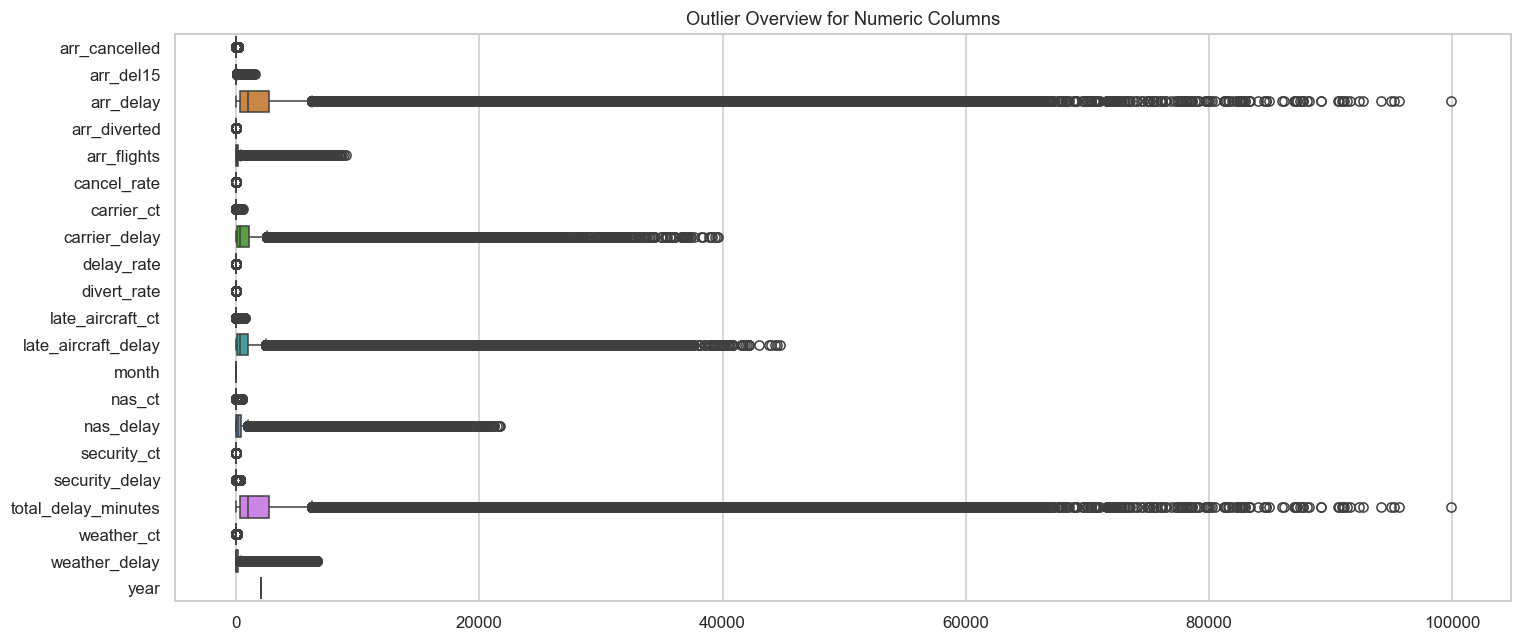

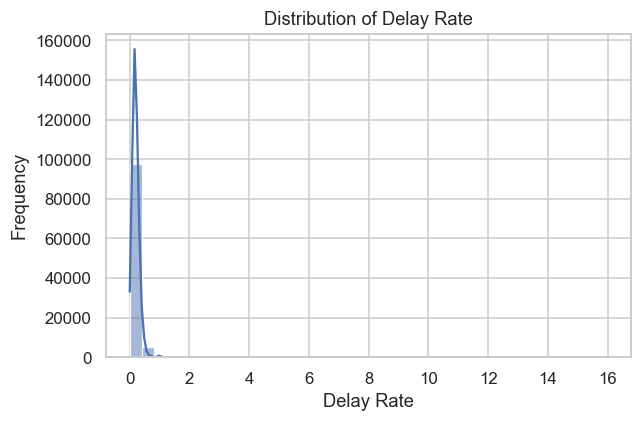

Mean Delay Rate: 0.204
Max Delay Rate: 16.000


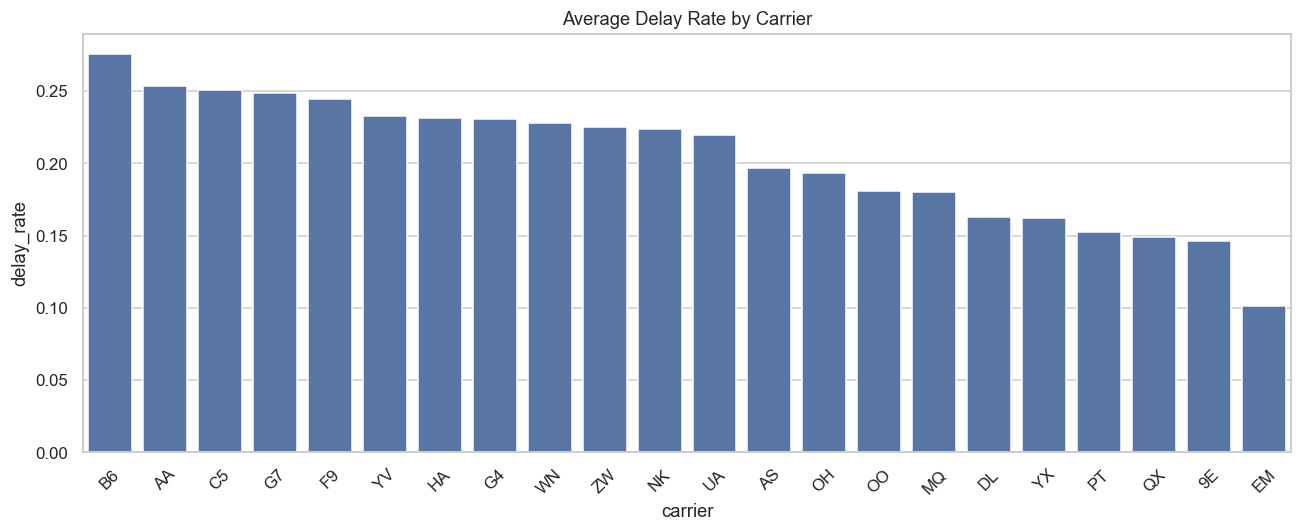

C:\Users\gowda\AppData\Local\Temp\ipykernel_7264\2142822700.py:99: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='month', y='delay_rate', data=df, estimator='mean', ci=None)


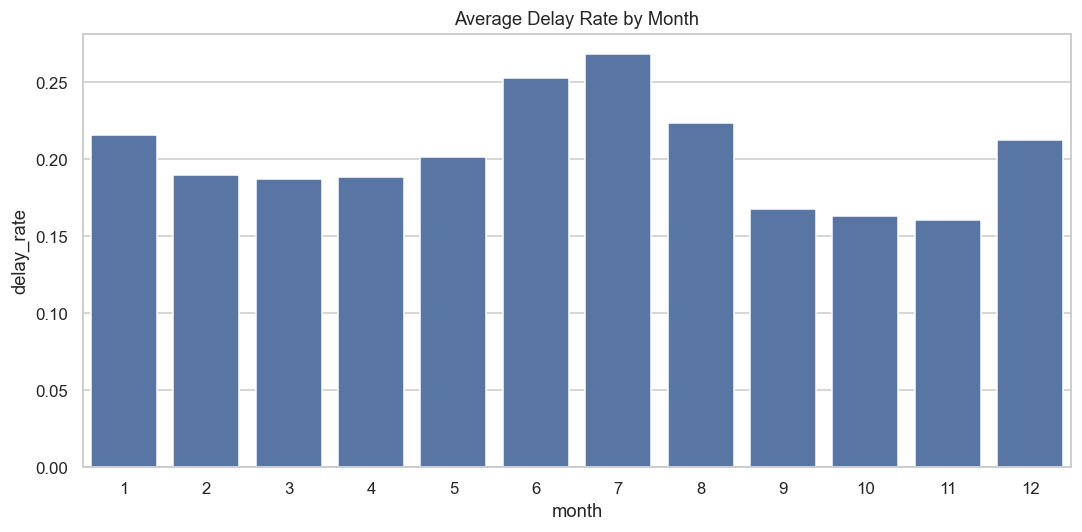

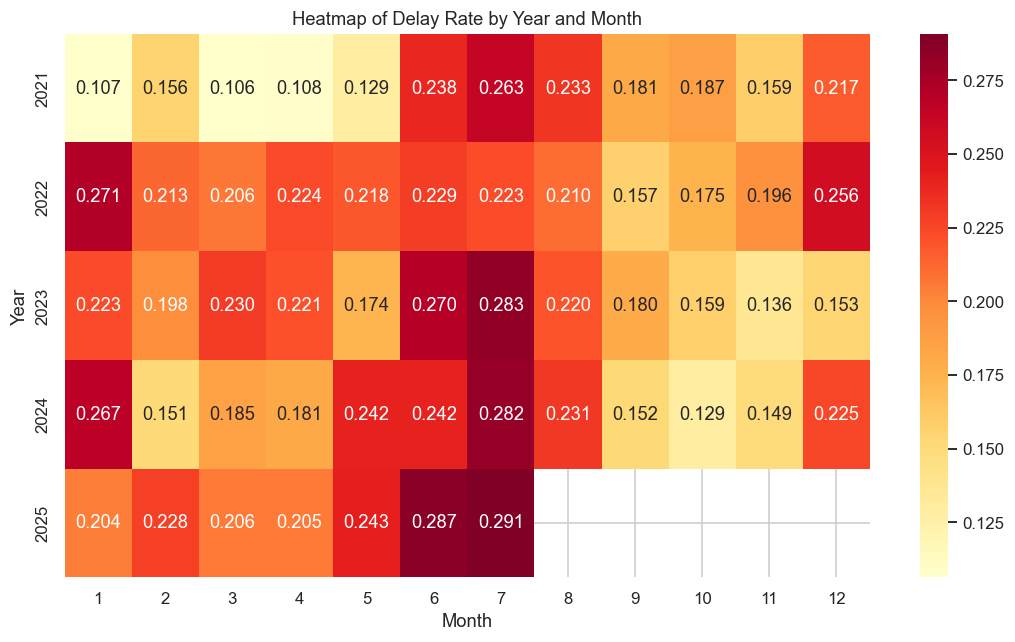

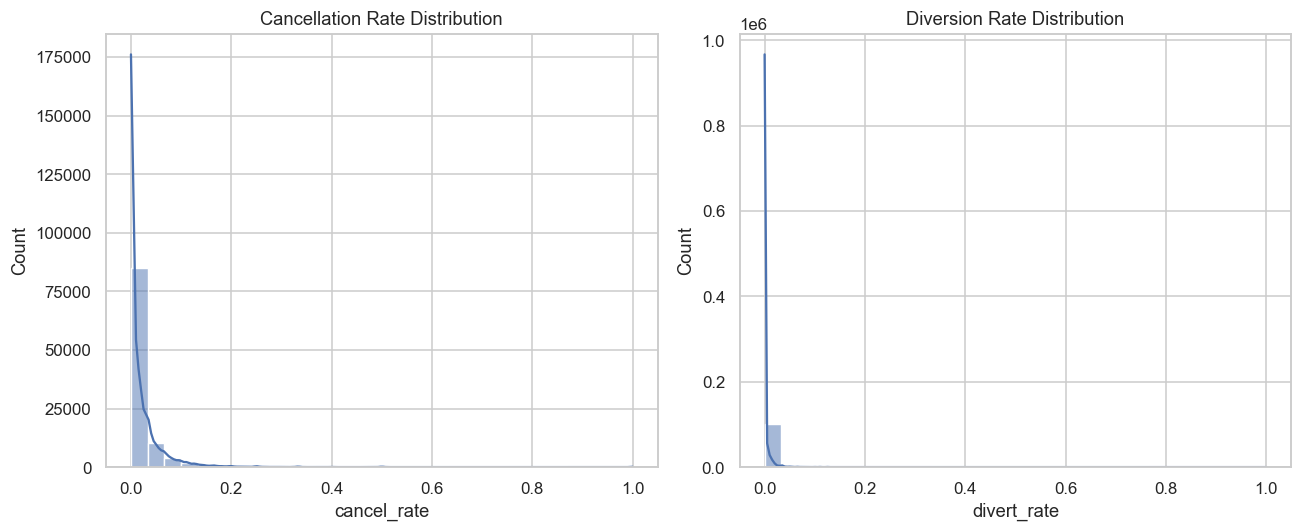

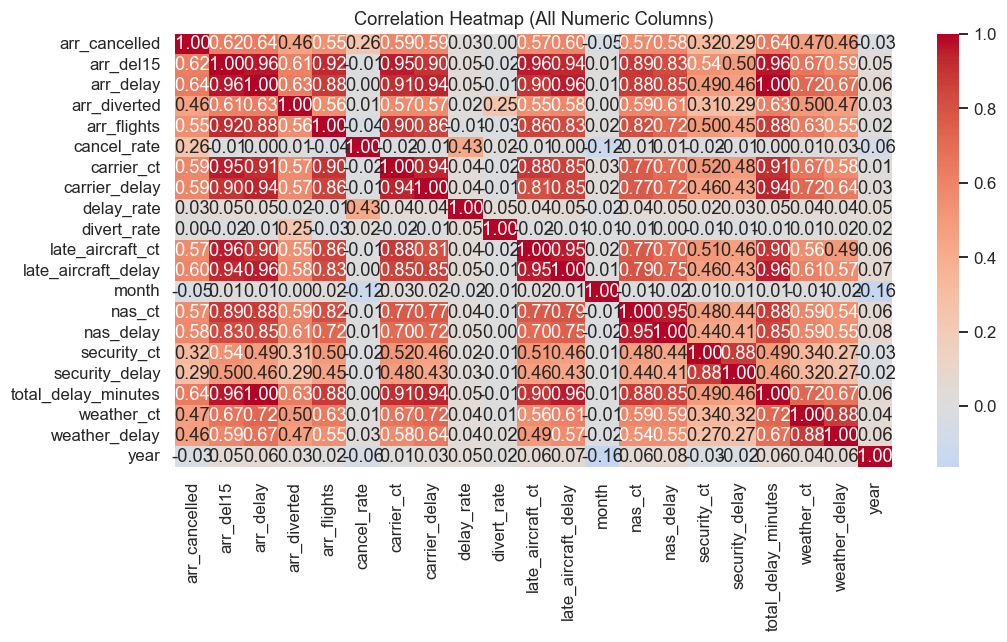


🔗 Top 10 correlations with delay_rate:
delay_rate             1.000000
cancel_rate            0.426555
late_aircraft_delay    0.052326
total_delay_minutes    0.048930
arr_delay              0.048929
divert_rate            0.047507
nas_delay              0.047073
year                   0.046279
arr_del15              0.045383
late_aircraft_ct       0.044061
Name: delay_rate, dtype: float64


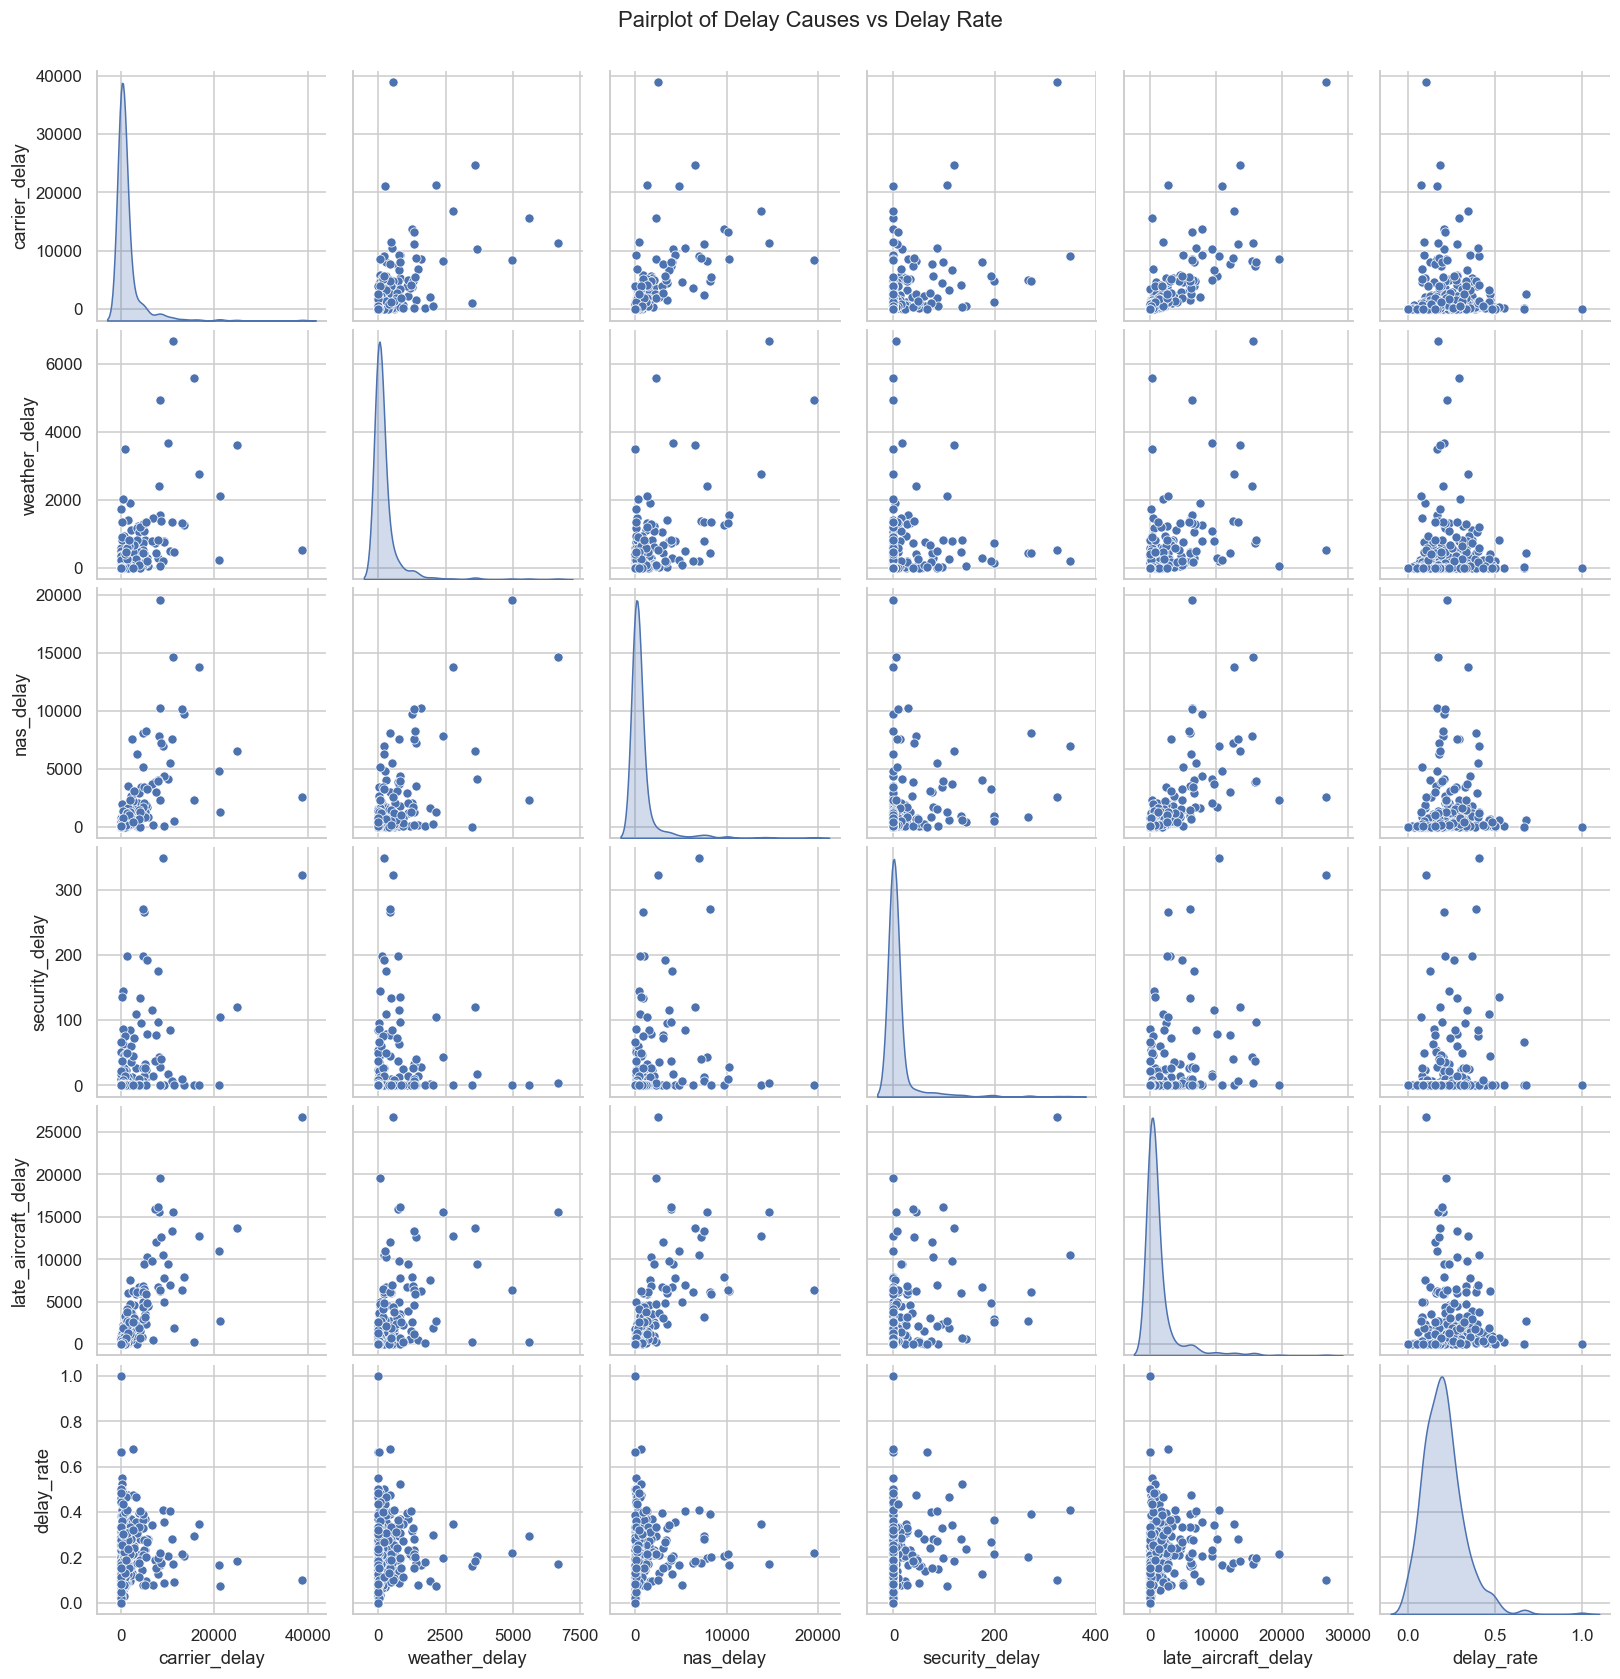

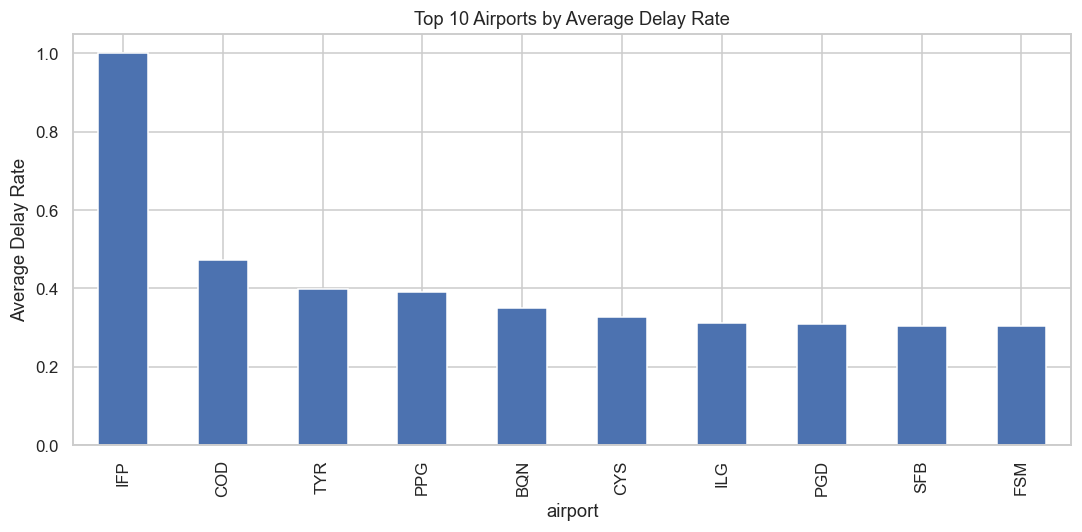

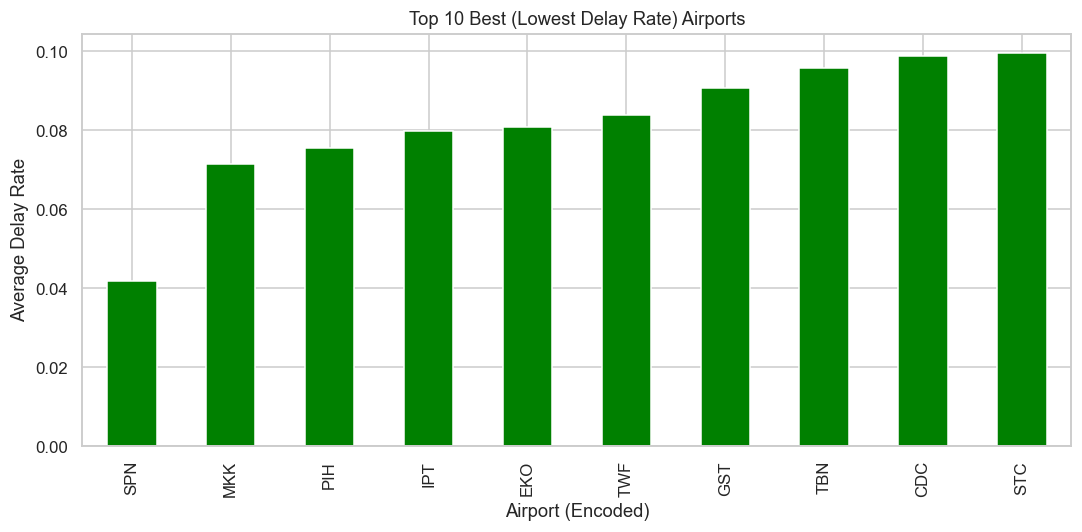

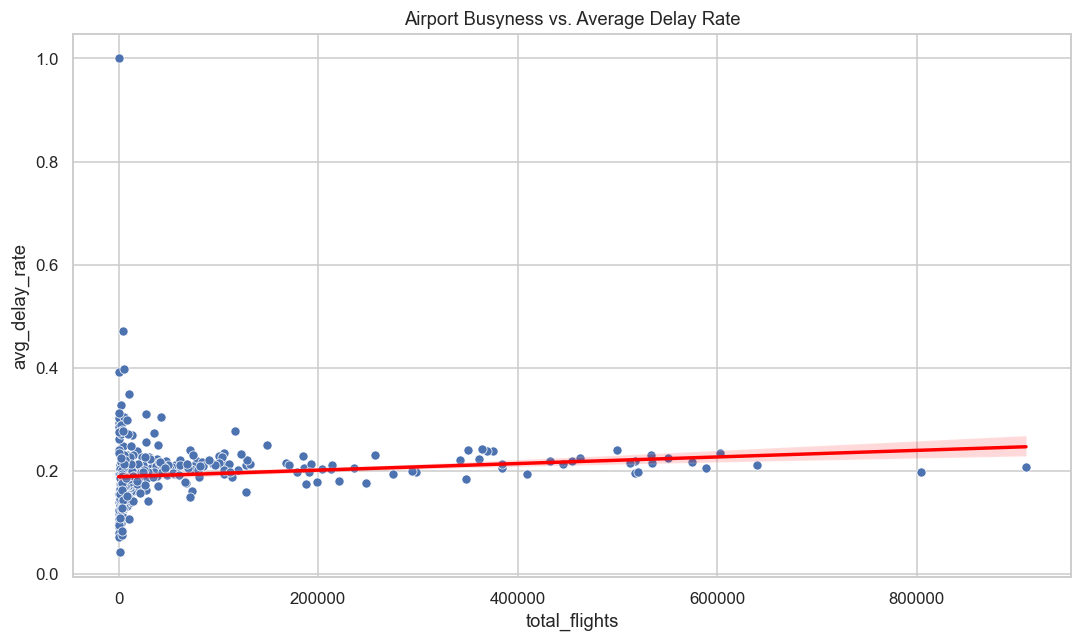

Correlation between Total Flights and Delay Rate: 0.1373


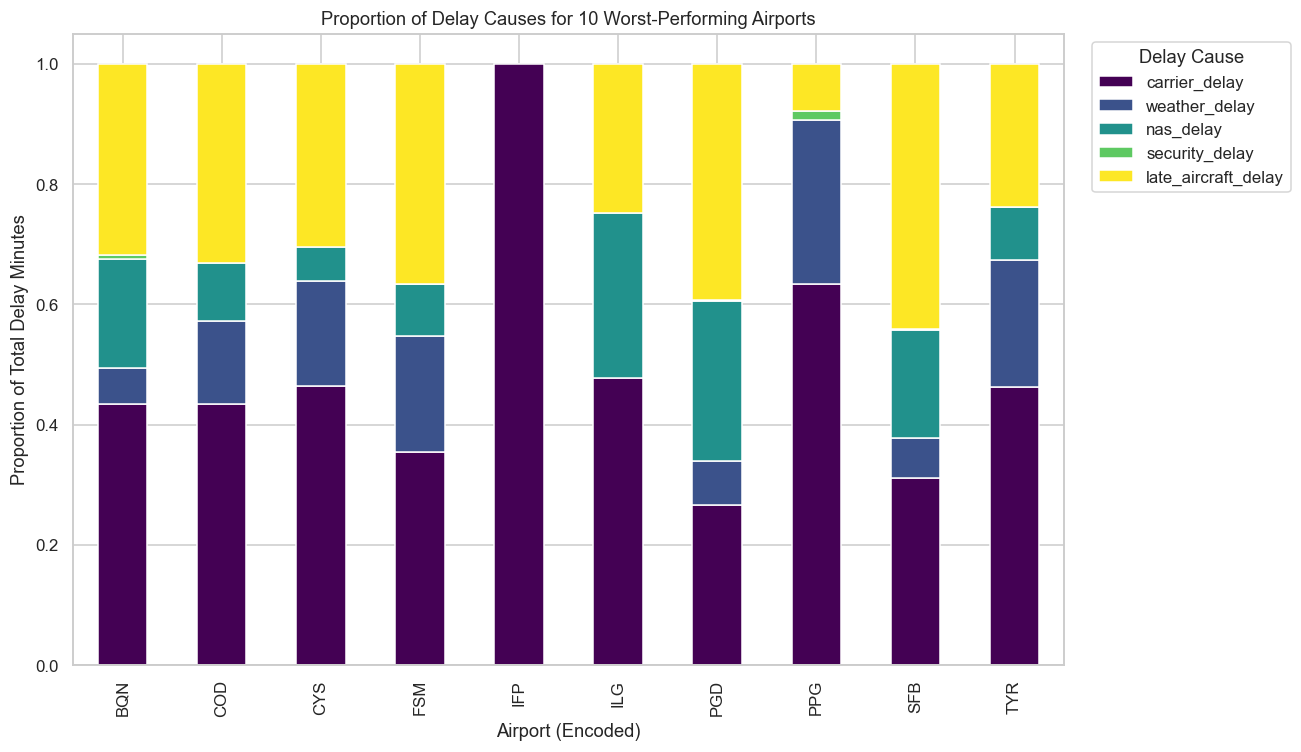

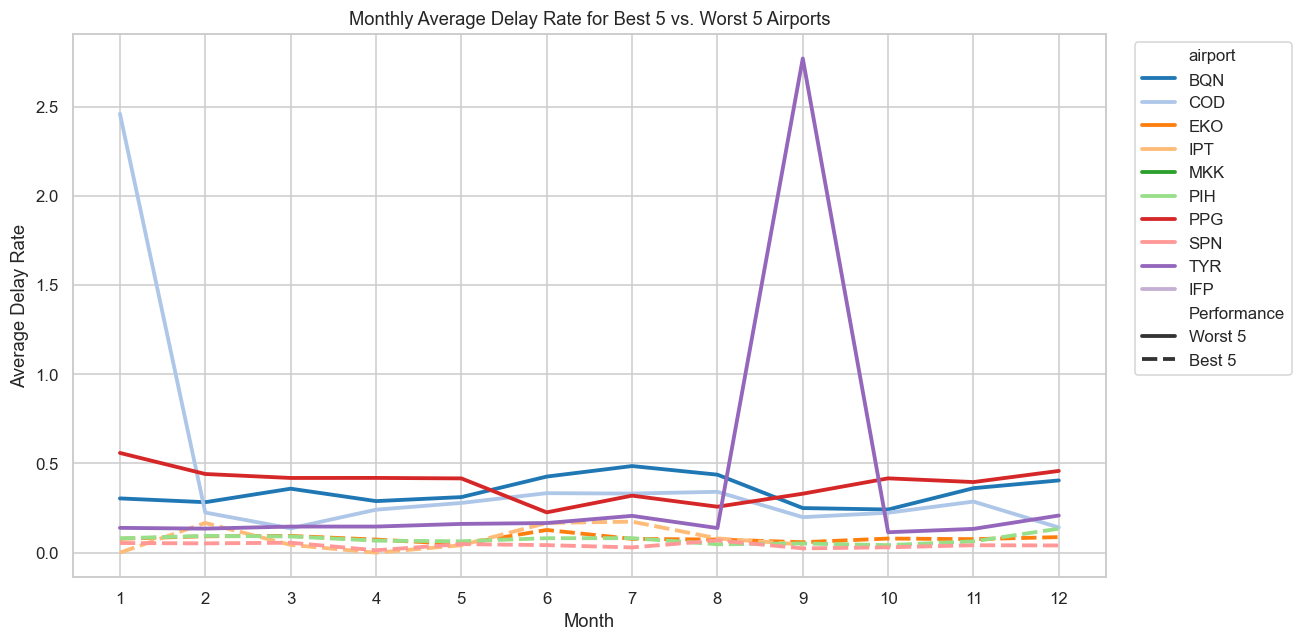


📈 Top 10 most skewed numeric features:
delay_rate          42.847465
divert_rate         20.847896
cancel_rate          8.523157
arr_cancelled        7.240595
security_delay       6.540368
arr_diverted         6.510097
security_ct          6.326735
late_aircraft_ct     6.207882
weather_ct           6.203978
nas_delay            6.014618
dtype: float64

✅ Final numeric columns ready for modeling:
['arr_cancelled', 'arr_del15', 'arr_delay', 'arr_diverted', 'arr_flights', 'cancel_rate', 'carrier_ct', 'carrier_delay', 'delay_rate', 'divert_rate', 'late_aircraft_ct', 'late_aircraft_delay', 'month', 'nas_ct', 'nas_delay', 'security_ct', 'security_delay', 'total_delay_minutes', 'weather_ct', 'weather_delay', 'year']

✅ Final categorical columns:
['airport', 'airport_name', 'carrier', 'carrier_name']

💾 Final dataset saved to: C:\Users\gowda\Downloads\FDS PROJECT\Airline_Flight_Delay_Prediction\dataset\flights_ready.csv
🖼️ Plots saved to: C:\Users\gowda\Downloads\FDS PROJECT\Airline_Flight_De

In [ ]:
# ---------------------------------------------------------
# Notebook: 03_eda.ipynb
# Purpose: Exploratory Data Analysis (EDA) for Airline Delay Prediction
# Dataset: flights_cleaned.csv
# Author: Kushalgowda
# ---------------------------------------------------------

# ===============================
# 1️ Imports and setup
# ===============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Style setup
sns.set(style="whitegrid", palette="deep")
plt.rcParams['figure.dpi'] = 110

# Paths
DATA_PATH = r"C:\Users\gowda\Downloads\FDS PROJECT\Airline_Flight_Delay_Prediction\dataset"
FILE_PATH = os.path.join(DATA_PATH, "flights_cleaned.csv")
PLOT_DIR = os.path.join(DATA_PATH, "plots")
os.makedirs(PLOT_DIR, exist_ok=True)

# ===============================
# 2️ Load dataset
# ===============================
df = pd.read_csv(FILE_PATH)
print(f" Dataset loaded → {df.shape[0]:,} rows × {df.shape[1]} columns")

# Normalize column names
df.columns = df.columns.str.strip().str.lower()

print("\n Columns in dataset:")
print(df.columns.tolist())

# ===============================
# 3️Dataset overview
# ===============================
print("\n Missing Values Summary:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

print("\nData Types Summary:")
print(df.dtypes.value_counts())

for col in ['year', 'month', 'carrier', 'airport']:
    if col in df.columns:
        print(f"{col}: {df[col].nunique()} unique values")

# ===============================
# 4️ Basic numeric overview
# ===============================
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
print("\n Numeric column summary:")
display(df[numeric_cols].describe().T)

# Boxplot for outlier visualization
plt.figure(figsize=(14,6))
sns.boxplot(data=df[numeric_cols], orient="h")
plt.title("Outlier Overview for Numeric Columns")
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "outlier_overview.png"))
plt.show()

# ===============================
# 5️ Delay distribution
# ===============================
if 'delay_rate' in df.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df['delay_rate'], bins=40, kde=True)
    plt.title("Distribution of Delay Rate")
    plt.xlabel("Delay Rate")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, "delay_rate_distribution.png"))
    plt.show()
    print(f"Mean Delay Rate: {df['delay_rate'].mean():.3f}")
    print(f"Max Delay Rate: {df['delay_rate'].max():.3f}")

# ===============================
# 6️ Delay rate by carrier
# ===============================
if {'carrier', 'delay_rate'}.issubset(df.columns):
    carrier_delay = df.groupby('carrier')['delay_rate'].mean().sort_values(ascending=False).reset_index()
    plt.figure(figsize=(12,5))
    sns.barplot(x='carrier', y='delay_rate', data=carrier_delay)
    plt.title("Average Delay Rate by Carrier")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, "delay_rate_by_carrier.png"))
    plt.show()

# ===============================
# 7️ Delay rate by month
# ===============================
if {'month', 'delay_rate'}.issubset(df.columns):
    plt.figure(figsize=(10,5))
    sns.barplot(x='month', y='delay_rate', data=df, estimator='mean', ci=None)
    plt.title("Average Delay Rate by Month")
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, "delay_rate_by_month.png"))
    plt.show()

# ===============================
# 8️ Delay heatmap by year & month
# ===============================
if {'year', 'month', 'delay_rate'}.issubset(df.columns):
    pivot = df.pivot_table(values='delay_rate', index='year', columns='month', aggfunc='mean')
    plt.figure(figsize=(10,6))
    sns.heatmap(pivot, annot=True, cmap='YlOrRd', fmt=".3f")
    plt.title("Heatmap of Delay Rate by Year and Month")
    plt.ylabel("Year")
    plt.xlabel("Month")
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, "heatmap_delayrate_year_month.png"))
    plt.show()

# ===============================
# 9️ Cancellation & Diversion Rates
# ===============================
if {'cancel_rate', 'divert_rate'}.issubset(df.columns):
    fig, ax = plt.subplots(1,2, figsize=(12,5))
    sns.histplot(df['cancel_rate'], bins=30, kde=True, ax=ax[0])
    sns.histplot(df['divert_rate'], bins=30, kde=True, ax=ax[1])
    ax[0].set_title("Cancellation Rate Distribution")
    ax[1].set_title("Diversion Rate Distribution")
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, "cancel_divert_rate.png"))
    plt.show()

# ===============================
#  Correlation Analysis
# ===============================
if 'delay_rate' in df.columns:
    corr = df.corr(numeric_only=True)
    plt.figure(figsize=(10,6))
    sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f")
    plt.title("Correlation Heatmap (All Numeric Columns)")
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, "correlation_heatmap.png"))
    plt.show()

    print("\n Top 10 correlations with delay_rate:")
    print(corr['delay_rate'].sort_values(ascending=False).head(10))

# ===============================
# 11️Delay causes relationship
# ===============================
cause_cols = ['carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay', 'delay_rate']
if all(c in df.columns for c in cause_cols):
    sns.pairplot(df[cause_cols].sample(n=min(500, len(df)), random_state=42), diag_kind='kde')
    plt.suptitle("Pairplot of Delay Causes vs Delay Rate", y=1.02)
    plt.savefig(os.path.join(PLOT_DIR, "pairplot_delay_causes.png"))
    plt.show()

# ===============================
# 12️Airport performance
# ===============================
if {'airport', 'delay_rate'}.issubset(df.columns):
    airport_delay = df.groupby('airport')['delay_rate'].mean().sort_values(ascending=False).head(10)
    airport_delay.plot(kind='bar', figsize=(10,5))
    plt.title("Top 10 Airports by Average Delay Rate")
    plt.ylabel("Average Delay Rate")
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, "airport_delay_rate_top10.png"))
    plt.show()

    # ===============================
# 12b. Top 10 Best (Lowest Delay Rate) Airports
# ===============================
if {'airport', 'delay_rate'}.issubset(df.columns):
    airport_delay_best = df.groupby('airport')['delay_rate'].mean().sort_values(ascending=True).head(10)
    
    plt.figure(figsize=(10,5))
    airport_delay_best.plot(kind='bar', color='green')
    plt.title("Top 10 Best (Lowest Delay Rate) Airports")
    plt.ylabel("Average Delay Rate")
    plt.xlabel("Airport (Encoded)")
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, "airport_delay_rate_best10.png"))
    plt.show()

# ===============================
# 12c. Airport Busyness vs. Delay Rate
# ===============================
if {'airport', 'arr_flights', 'delay_rate'}.issubset(df.columns):
    airport_summary = df.groupby('airport').agg(
        total_flights=('arr_flights', 'sum'),
        avg_delay_rate=('delay_rate', 'mean')
    ).reset_index()

    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=airport_summary, 
        x='total_flights', 
        y='avg_delay_rate'
    )
    plt.title('Airport Busyness vs. Average Delay Rate')
    plt.xlabel('Total Arriving Flights (in sample)')
    plt.ylabel('Average Delay Rate')
    sns.regplot(
        data=airport_summary, 
        x='total_flights', 
        y='avg_delay_rate', 
        scatter=False, 
        color='red'
    )
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, "airport_busyness_vs_delay.png"))
    plt.show()

    correlation = airport_summary['total_flights'].corr(airport_summary['avg_delay_rate'])
    print(f"Correlation between Total Flights and Delay Rate: {correlation:.4f}")

# ===============================
# 12d. Delay Cause Analysis for Worst Airports
# ===============================
delay_cause_cols = ['carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']

if {'airport', 'delay_rate'}.issubset(df.columns) and all(c in df.columns for c in delay_cause_cols):
    worst_airports_list = df.groupby('airport')['delay_rate'].mean().sort_values(ascending=False).head(10).index.tolist()
    worst_airports_df = df[df['airport'].isin(worst_airports_list)]
    cause_summary = worst_airports_df.groupby('airport')[delay_cause_cols].mean()
    cause_summary_pct = cause_summary.divide(cause_summary.sum(axis=1), axis=0)
    cause_summary_pct.plot(
        kind='bar', 
        stacked=True, 
        figsize=(12, 7), 
        cmap='viridis'
    )
    plt.title('Proportion of Delay Causes for 10 Worst-Performing Airports')
    plt.ylabel('Proportion of Total Delay Minutes')
    plt.xlabel('Airport (Encoded)')
    plt.legend(title='Delay Cause', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, "airport_delay_cause_stacked.png"))
    plt.show()

# ===============================
# 12e. Seasonal Delay Patterns for Key Airports
# ===============================
if {'airport', 'month', 'delay_rate'}.issubset(df.columns):
    worst_5_list = df.groupby('airport')['delay_rate'].mean().sort_values(ascending=False).head(5).index.tolist()
    best_5_list = df.groupby('airport')['delay_rate'].mean().sort_values(ascending=True).head(5).index.tolist()
    key_airports_list = worst_5_list + best_5_list
    
    key_airports_df = df[df['airport'].isin(key_airports_list)].copy()
    key_airports_df['Performance'] = key_airports_df['airport'].apply(lambda x: 'Worst 5' if x in worst_5_list else 'Best 5')
    seasonal_data = key_airports_df.groupby(['month', 'airport', 'Performance'])['delay_rate'].mean().reset_index()

    plt.figure(figsize=(12, 6))
    sns.lineplot(
        data=seasonal_data, 
        x='month', 
        y='delay_rate', 
        hue='airport', 
        style='Performance', 
        palette='tab20',
        linewidth=2.5
    )
    plt.title('Monthly Average Delay Rate for Best 5 vs. Worst 5 Airports')
    plt.xlabel('Month')
    plt.ylabel('Average Delay Rate')
    plt.xticks(range(1, 13))
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, "airport_seasonal_performance.png"))
    plt.show()


# ===============================
# 13️Skewness & Feature Readiness
# ===============================
skews = df[numeric_cols].skew().sort_values(ascending=False)
print("\n Top 10 most skewed numeric features:")
print(skews.head(10))

print("\n Final numeric columns ready for modeling:")
print(df.select_dtypes(include=[float, int]).columns.tolist())

print("\n Final categorical columns:")
print(df.select_dtypes(exclude=[float, int]).columns.tolist())

# ===============================
# 14️ Save dataset for modeling
# ===============================

# Preserve original column order
df = df.reindex(sorted(df.columns), axis=1)

FINAL_PATH = os.path.join(DATA_PATH, "flights_ready.csv")
df.to_csv(FINAL_PATH, index=False)
print(f"\n Final dataset saved to: {FINAL_PATH}")
print(f" Plots saved to: {PLOT_DIR}")
print("\n EDA complete.")

# ===============================
# 15️Power BI dataset creation
# ===============================
powerbi_cols = ['year', 'month', 'carrier', 'airport', 
                'delay_rate', 'cancel_rate', 'divert_rate', 
                'total_delay_minutes']
df[powerbi_cols].to_csv(os.path.join(DATA_PATH, "flights_powerbi.csv"), index=False)

print(f"Power BI dataset columns: {powerbi_cols}")
print(f"Power BI CSV saved → {os.path.join(DATA_PATH, 'flights_powerbi.csv')}")
